# **SERIES TEMPORALES**
## **Sistema de Predicción de Ventas — Modelo ARIMA**

# **PASO 1: Carga del conjunto de datos**

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
# Carga del dataset de ventas
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
df = pd.read_csv(url)

print("Shape del dataset:", df.shape)
print("Columnas:", list(df.columns))
df.head(10)

Shape del dataset: (366, 2)
Columnas: ['date', 'sales']


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
5,2022-09-08 17:10:08.079328,60.081865
6,2022-09-09 17:10:08.079328,68.466704
7,2022-09-10 17:10:08.079328,67.765106
8,2022-09-11 17:10:08.079328,70.512261
9,2022-09-12 17:10:08.079328,74.656453


Este dataset tiene **366 filas y 2 columnas**, ambas columnas tienen variables númericas, una hace referencia a fechas y la otra a cantidades de dinero.

In [31]:
# Exploración inicial
print("INFORMACIÓN GENERAL")
df.info()

print("n\ ESTADÍSTICAS DESCRIPTIVAS")
print(df.describe())

print("\nVALORES NULOS")
print(df.isnull().sum())

print("\nPRIMERAS Y ÚLTIMAS FILAS")
print(df.head(3))
print("...")
print(df.tail(3))

INFORMACIÓN GENERAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    366 non-null    object 
 1   sales   366 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.8+ KB
n\ ESTADÍSTICAS DESCRIPTIVAS
             sales
count   366.000000
mean    524.963968
std     275.089698
min      53.803211
25%     290.186822
50%     520.699468
75%     763.289263
max    1000.482785

VALORES NULOS
date     0
sales    0
dtype: int64

PRIMERAS Y ÚLTIMAS FILAS
                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
...
                           date        sales
363  2023-09-01 17:10:08.079328   995.814415
364  2023-09-02 17:10:08.079328   997.350214
365  2023-09-03 17:10:08.079328  1000.482785


La exploración inicial nos permite entender el formato del dataset: vemos las estadísticas descriptivas, que el dataset no cuenta con valores nulos y podemos apreciar que va de septiembre del 2022 al septiembre del 2023.

# **PASO 2: Construcción y análisis de la serie temporal**

In [32]:
# Detectamos la columna de fecha y la convertimos al índice
date_col  = df.columns[0]   # primera columna = fecha
value_col = df.columns[1]   # segunda columna = ventas

df[date_col] = pd.to_datetime(df[date_col])
df = df.set_index(date_col).sort_index()
serie = df[value_col]

print(f"Columna de fecha : {date_col}")
print(f"Columna de ventas: {value_col}")
print(f"Rango temporal   : {serie.index.min().date()} → {serie.index.max().date()}")
print(f"Número de puntos : {len(serie)}")
print(f"Frecuencia       : {pd.infer_freq(serie.index)}")

Columna de fecha : date
Columna de ventas: sales
Rango temporal   : 2022-09-03 → 2023-09-03
Número de puntos : 366
Frecuencia       : D


Construimos la estructura de datos en base a la serie temporal: convierto la columna de fecha a tipo `datetime` y la establezco como índice del DataFrame. `pd.infer_freq()` indica automáticamente el **tensor** (unidad mínima de tiempo) de la serie: `MS` es mensual, `D` es diaria, `W` semanal, etc.

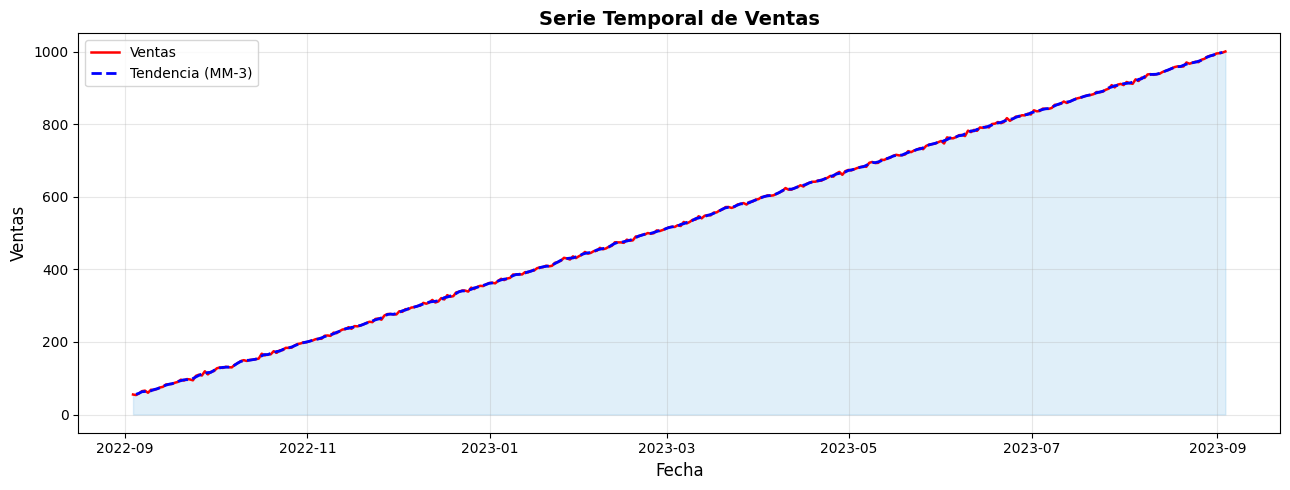

In [33]:
# Gráfica de la serie temporal completa
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(serie.index, serie.values, color='red', linewidth=1.8, label='Ventas')
ax.fill_between(serie.index, serie.values, alpha=0.15, color='#3498db')

# Línea de tendencia
media_movil = serie.rolling(window=3, center=True).mean()
ax.plot(media_movil.index,
        media_movil.values,
        color='blue',
        linewidth=2,
        linestyle='--',
        label='Tendencia (MM-3)')

ax.set_title('Serie Temporal de Ventas', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La gráfica muestra la evolución de las ventas en el año junto con una **media móvil de 3 períodos** (línea roja) que suaviza el ruido y nos permite ver la tendencia con más claridad. Según el enunciado del proyecto, las ventas han ido en aumento desde la creación de la empresa y como podemos observar el gráfico muestra una **tendencia creciente**.

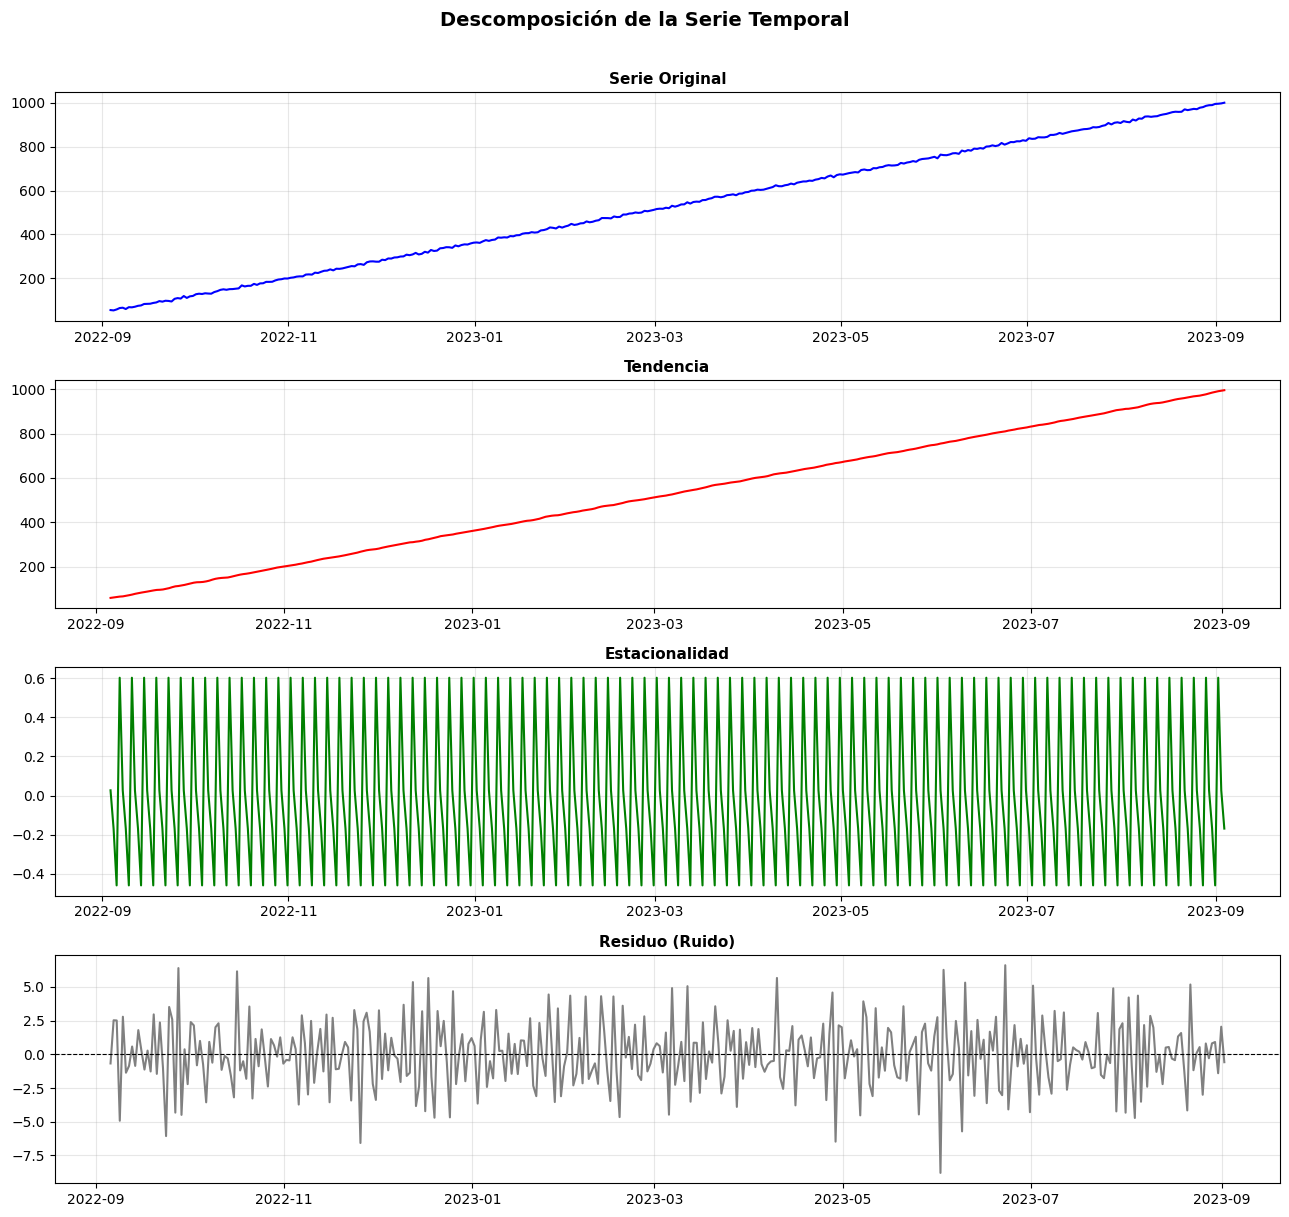

In [34]:
# Descomposición de la serie temporal
# period=12 para series mensuales (ajustar si el tensor es distinto)
try:
    freq = pd.infer_freq(serie.index)
    period = 12 if freq in ['MS', 'M', 'ME'] else (52 if 'W' in str(freq) else 4)
except:
    period = 12

decomposicion = seasonal_decompose(serie, model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(13, 12))

componentes = [
    (decomposicion.observed,  'Serie Original',   'blue'),
    (decomposicion.trend,     'Tendencia',         'red'),
    (decomposicion.seasonal,  'Estacionalidad',    'green'),
    (decomposicion.resid,     'Residuo (Ruido)',   'grey'),
]

for ax, (comp, titulo, color) in zip(axes, componentes):
    ax.plot(comp.index,
            comp.values,
            color=color,
            linewidth=1.5)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if titulo == 'Residuo (Ruido)':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.suptitle('Descomposición de la Serie Temporal', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La descomposición aditiva separa la serie en sus tres componentes:

- **Tendencia** (rojo): el patrón a largo plazo. Si sube de forma sostenida, nos confirma la tendencia **creciente** que mencionaba el enunciado del proyecto.
- **Estacionalidad** (verde): patrones que se repiten periódicamente. Si las oscilaciones son regulares y de amplitud constante, hay estacionalidad, como apreciamos en el gráfico.
- **Residuo / ruido** (gris): lo que queda después de extraer tendencia y estacionalidad. Si los residuos son pequeños y aleatorios (en torno a 0), el modelo aditivo es adecuado. Si tienen estructura, habría que considerar un modelo multiplicativo.

In [35]:
# Test de Dickey-Fuller aumentado (ADF) — prueba de estacionariedad
resultado_adf = adfuller(serie.dropna(), autolag='AIC')

print("  TEST DE DICKEY-FULLER AUMENTADO (ADF)")
print(f"  Estadístico ADF : {resultado_adf[0]:.4f}")
print(f"  p-valor         : {resultado_adf[1]:.6f}")
print(f"  Lags utilizados : {resultado_adf[2]}")
print(f"  Observaciones   : {resultado_adf[3]}")
print("\n  Valores críticos:")
for nivel, valor in resultado_adf[4].items():
    print(f"    {nivel}: {valor:.4f}")

if resultado_adf[1] < 0.05:
    print("  La serie ES ESTACIONARIA (p < 0.05)")
    print("     Se rechaza la hipótesis nula de raíz unitaria.")
else:
    print("  La serie NO ES ESTACIONARIA (p >= 0.05)")
    print("     No se puede rechazar la hipótesis nula de raíz unitaria.")
    print("     Será necesario diferenciar la serie (d >= 1) en ARIMA.")

  TEST DE DICKEY-FULLER AUMENTADO (ADF)
  Estadístico ADF : 0.5454
  p-valor         : 0.986190
  Lags utilizados : 13
  Observaciones   : 352

  Valores críticos:
    1%: -3.4491
    5%: -2.8698
    10%: -2.5712
  La serie NO ES ESTACIONARIA (p >= 0.05)
     No se puede rechazar la hipótesis nula de raíz unitaria.
     Será necesario diferenciar la serie (d >= 1) en ARIMA.


**¿Cuál es el tensor?**
La unidad mínima de tiempo detectada por `pd.infer_freq()` en la celda anterior. Si es `MS` (Month Start), el tensor es **mensual**: hay un solo dato por mes.

**¿Cuál es la tendencia?**
La componente de tendencia de la descomposición muestra una **tendencia creciente**, tal y con lo descrito en el enunciado: las ventas han aumentado desde la creación de la empresa.

**¿Es estacionaria?**
El test ADF comprueba si la serie tiene raíz unitaria (no estacionaria). Con p-valor < 0.05 rechaza la hipótesis nula y la serie **sí es estacionaria**. Con p-valor ≥ 0.05, la serie **no es estacionaria** y necesita diferenciación (parámetro `d` en ARIMA ≥ 1).

**¿Existe variabilidad o ruido?**
La componente residual de la descomposición muestra el nivel de ruido. Si los residuos son pequeños y sin estructura visible, el ruido es bajo. Si oscilan con amplitud importante, hay variabilidad significativa que el modelo debe capturar.

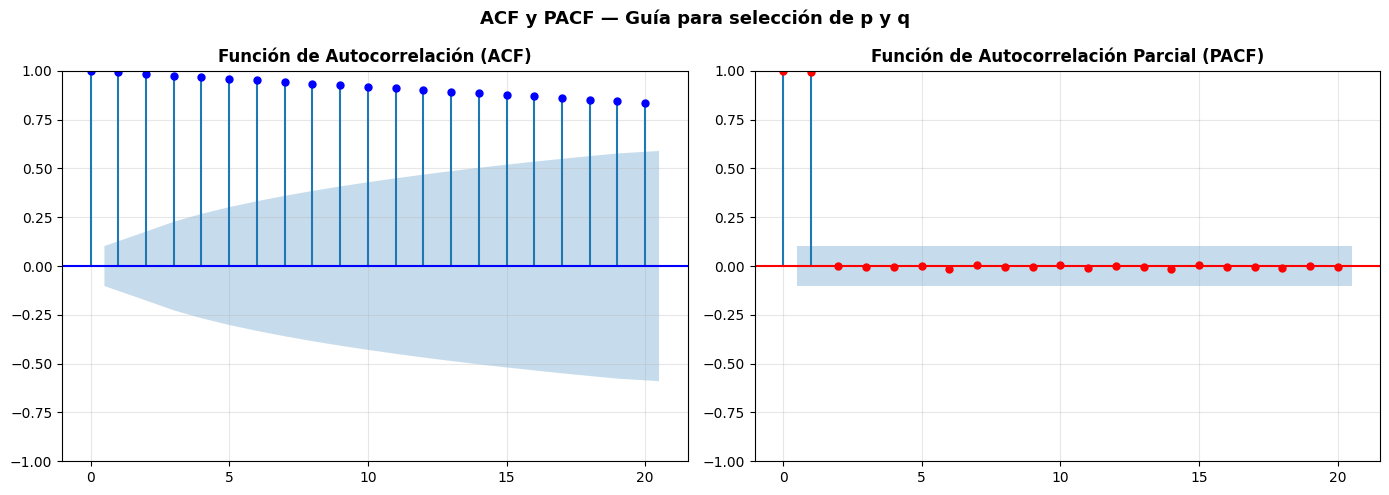

In [36]:
# Gráficas ACF y PACF para determinar los parámetros p y q de ARIMA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(serie.dropna(),
         lags=20,
         ax=axes[0],
         color='blue')
axes[0].set_title('Función de Autocorrelación (ACF)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

plot_pacf(serie.dropna(),
          lags=20,
          ax=axes[1],
          color='red',
          method='ywm')
axes[1].set_title('Función de Autocorrelación Parcial (PACF)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ACF y PACF — Guía para selección de p y q', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Los correlograma ACF y PACF son herramientas clave para determinar los parámetros `p` y `q` del modelo ARIMA:

- **ACF (Autocorrelación)**: mide la correlación de la serie consigo misma. El número de lags **significativos** (que superan las bandas de confianza azules) antes de que se corten indica el orden **q** (MA).
- **PACF (Autocorrelación Parcial)**: elimina el efecto de lags intermedios. El número de lags significativos indica el orden **p** (AR).

Si la ACF decrece lentamente (no se corta), nos confirma que la serie **no es estacionaria** y necesita diferenciación (`d > 0`).

# **PASO 3: División train/test y entrenamiento del modelo ARIMA**

Total de puntos : 366
Train           : 293 puntos  (2022-09-03 → 2023-06-22)
Test            : 73  puntos  (2023-06-23 → 2023-09-03)


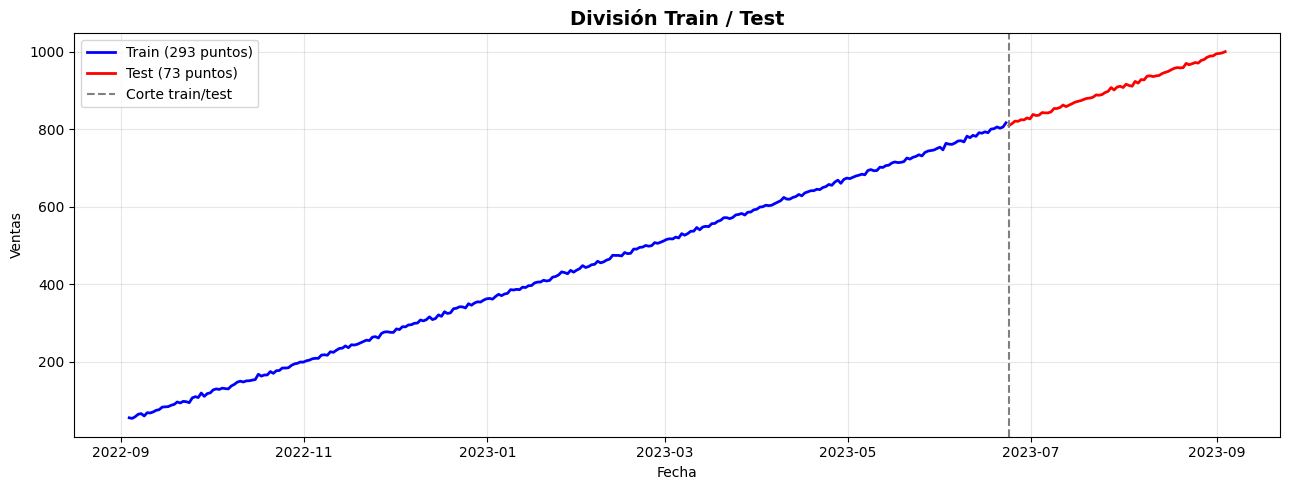

In [37]:
# División train/test: 80% entrenamiento, 20% prueba
n_total = len(serie)
n_test  = max(int(n_total * 0.2), 6)   # mínimo 6 puntos en test
n_train = n_total - n_test

train = serie.iloc[:n_train]
test  = serie.iloc[n_train:]

print(f"Total de puntos : {n_total}")
print(f"Train           : {n_train} puntos  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Test            : {n_test}  puntos  ({test.index.min().date()} → {test.index.max().date()})")

# Visualización del split
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train.index,
        train.values,
        color='blue',
        linewidth=2,
        label=f'Train ({n_train} puntos)')
ax.plot(test.index,
        test.values,
        color='red',
        linewidth=2,
        label=f'Test ({n_test} puntos)')
ax.axvline(test.index[0], color='gray', linestyle='--', linewidth=1.5, label='Corte train/test')
ax.set_title('División Train / Test', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dividimos la serie en **80% entrenamiento** y **20% test**, respetando el orden temporal. Esta división cronológica es obligatoria en series temporales: no se puede usar datos futuros para predecir el pasado. La línea gris discontinua marca el punto de corte. El conjunto de test simula los puntos que el modelo deberá predecir para la dirección de la empresa en un futuro inmediato.

In [38]:
# Búsqueda de la mejor parametrización ARIMA (p, d, q)
# Prueba de combinaciones y seleccionamos la de menor AIC
from itertools import product

p_values = range(0, 4)
d_values = range(0, 3)
q_values = range(0, 4)

mejores_resultados = []

print("Buscando mejor parametrización ARIMA(p,d,q)...")
for p, d, q in product(p_values, d_values, q_values):
    try:
        modelo = ARIMA(train, order=(p, d, q))
        resultado = modelo.fit()
        mejores_resultados.append({
            'p': p, 'd': d, 'q': q,
            'AIC': round(resultado.aic, 2),
            'BIC': round(resultado.bic, 2)
        })
    except:
        pass

resultados_df = pd.DataFrame(mejores_resultados).sort_values('AIC').reset_index(drop=True)

print("\nTop 10 mejores combinaciones por AIC:")
print(resultados_df.head(10).to_string(index=False))

mejor_p = resultados_df.iloc[0]['p']
mejor_d = resultados_df.iloc[0]['d']
mejor_q = resultados_df.iloc[0]['q']

print(f"\n Mejor parametrización: ARIMA({int(mejor_p)}, {int(mejor_d)}, {int(mejor_q)})")
print(f"   AIC: {resultados_df.iloc[0]['AIC']}")

Buscando mejor parametrización ARIMA(p,d,q)...

Top 10 mejores combinaciones por AIC:
 p  d  q     AIC     BIC
 0  2  3 1490.84 1505.54
 1  2  2 1490.95 1505.64
 0  2  2 1491.63 1502.65
 2  2  2 1492.81 1511.17
 2  2  3 1494.92 1516.96
 3  2  2 1494.99 1517.03
 1  2  3 1495.62 1513.99
 3  2  3 1496.79 1522.50
 1  1  3 1497.65 1516.03
 2  1  2 1498.06 1516.45

 Mejor parametrización: ARIMA(0, 2, 3)
   AIC: 1490.84


Busco la mejor parametrización ARIMA probando todas las combinaciones de:
- **p** (0–3): orden autorregresivo — cuántos valores pasados usa el modelo.
- **d** (0–2): grado de diferenciación — cuántas veces hay que diferenciar para hacer la serie estacionaria.
- **q** (0–3): orden de la media móvil — cuántos errores pasados incorpora el modelo.

Selecciono la combinación con menor **AIC** (Akaike Information Criterion), que penaliza la complejidad del modelo. Un AIC más bajo indica mejor balance entre ajuste y parsimonia.

In [39]:
# Entrenamiento del modelo final con los mejores parámetros
modelo_arima = ARIMA(train, order=(int(mejor_p), int(mejor_d), int(mejor_q)))
resultado_arima = modelo_arima.fit()

print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  293
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -741.422
Date:                Mon, 27 Apr 2026   AIC                           1490.843
Time:                        03:31:19   BIC                           1505.537
Sample:                    09-03-2022   HQIC                          1496.729
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0132      0.151    -13.319      0.000      -2.309      -1.717
ma.L2          1.1060      0.185      5.971      0.000       0.743       1.469
ma.L3         -0.0927      0.059     -1.568      0.1

### 📝 Comentario
El resumen del modelo muestra los coeficientes de los términos AR y MA, sus p-valores (significación estadística), el AIC/BIC final y diagnósticos del ajuste. Los coeficientes con p-valor < 0.05 son muy significativos y contribuyen de forma activa al modelo.

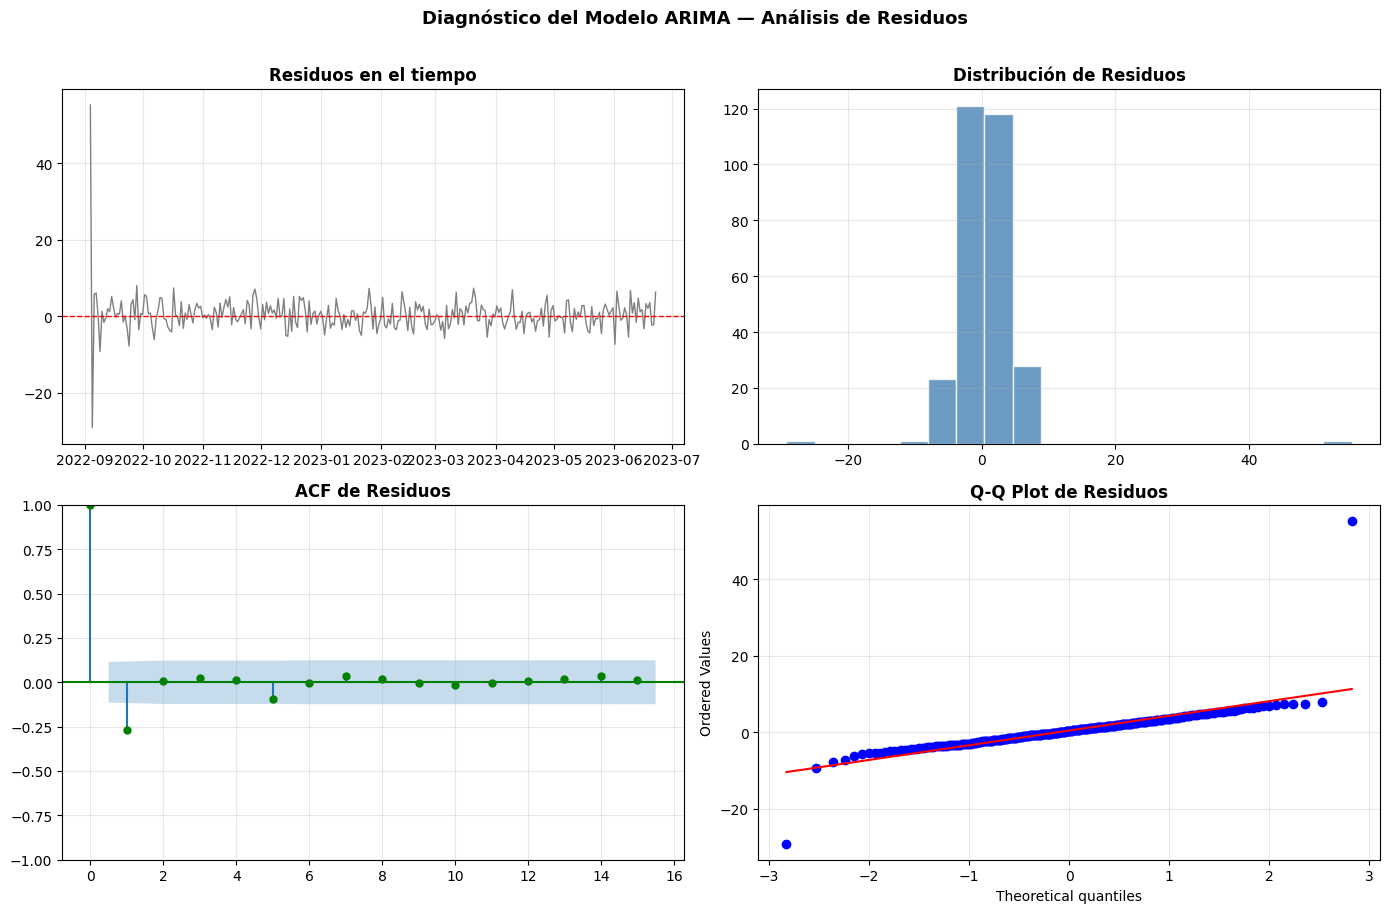

In [40]:
# Diagnóstico de residuos del modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

residuos = resultado_arima.resid

# Residuos en el tiempo
axes[0,0].plot(residuos.index,
               residuos.values,
               color='grey',
               linewidth=1)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('Residuos en el tiempo', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

# Histograma de residuos
axes[0,1].hist(residuos.dropna(),
               bins=20,
               color='steelblue',
               edgecolor='white',
               alpha=0.8)
axes[0,1].set_title('Distribución de Residuos', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

# ACF de residuos
plot_acf(residuos.dropna(),
         lags=15,
         ax=axes[1,0],
         color='green')
axes[1,0].set_title('ACF de Residuos', fontweight='bold')
axes[1,0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuos.dropna(),
               dist='norm',
               plot=axes[1,1])
axes[1,1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Diagnóstico del Modelo ARIMA — Análisis de Residuos',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

El diagnóstico de residuos valida la calidad del modelo. Un buen modelo ARIMA debe producir residuos y que se comporten como **ruido blanco**:
- **Residuos en el tiempo**: deben variar aleatoriamente en torno a 0, sin patrones visibles.
- **Histograma**: debe parecerse a una distribución normal centrada alrededor 0.
- **ACF de residuos**: no debe haber lags significativos fuera de las bandas. Si los hay, el modelo no ha capturado correctamente toda la estructura de la serie.
- **Q-Q Plot**: los puntos deben seguir la línea diagonal, indicando normalidad de los residuos.

# **PASO 4: Predicción con el conjunto de test**

In [41]:
# Predicción sobre el conjunto de test
predicciones = resultado_arima.forecast(steps=n_test)
predicciones.index = test.index

# Métricas de rendimiento
mae  = mean_absolute_error(test, predicciones)
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test.values - predicciones.values) / test.values)) * 100

print("  MÉTRICAS DE RENDIMIENTO")
print(f"  MAE  (Error Absoluto Medio)       : {mae:.4f}")
print(f"  RMSE (Raíz Error Cuadrático Medio): {rmse:.4f}")
print(f"  MAPE (Error Porcentual Absoluto)  : {mape:.2f}%")

  MÉTRICAS DE RENDIMIENTO
  MAE  (Error Absoluto Medio)       : 2.4127
  RMSE (Raíz Error Cuadrático Medio): 2.9464
  MAPE (Error Porcentual Absoluto)  : 0.27%


Predecimos los `n_test` puntos del periodo de prueba usando `forecast()`. Las métricas de rendimiento cuantifican cómo de cerca están las predicciones de los valores reales:

- **MAE** (Mean Absolute Error): error medio en las mismas unidades que las ventas. Fácil de interpretar.
- **RMSE** (Root Mean Squared Error): penaliza más los errores grandes. Siempre ≥ MAE.
- **MAPE** (Mean Absolute Percentage Error): error en porcentaje. Un MAPE con < 10% se considera muy bueno y con < 20% aceptable.

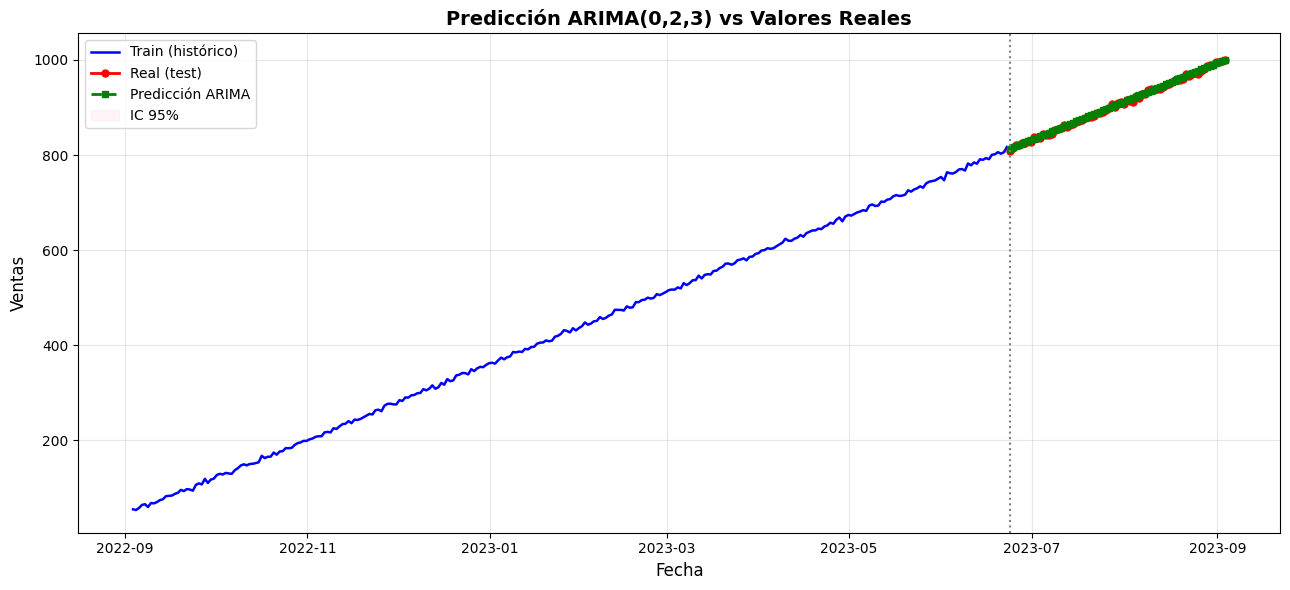

In [42]:
# Visualización: predicciones vs valores reales
# Intervalo de confianza del 95%
prediccion_conf = resultado_arima.get_forecast(steps=n_test)
ic = prediccion_conf.conf_int(alpha=0.05)
ic.index = test.index

fig, ax = plt.subplots(figsize=(13, 6))

# Serie histórica (train)
ax.plot(train.index,
        train.values,
        color='blue',
        linewidth=1.8,
        label='Train (histórico)')

# Valores reales del test
ax.plot(test.index,
        test.values,
        color='red',
        linewidth=2,
        marker='o',
        markersize=5,
        label='Real (test)')

# Predicciones
ax.plot(predicciones.index,
        predicciones.values,
        color='green',
        linewidth=2,
        marker='s',
        markersize=5,
        linestyle='--',
        label='Predicción ARIMA')

# Intervalo de confianza al 95%
ax.fill_between(test.index,
                ic.iloc[:, 0],
                ic.iloc[:, 1],
                color='pink',
                alpha=0.15,
                label='IC 95%')

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5)
ax.set_title(f'Predicción ARIMA({int(mejor_p)},{int(mejor_d)},{int(mejor_q)}) vs Valores Reales',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Este gráfico compara directamente las predicciones (verde discontinuo) con los valores reales del test (rojo). El **intervalo de confianza al 95%** (banda rosa semitransparente) indica la incertidumbre del modelo: cuanto más lejos en el tiempo, más se ensancha la banda. Un buen modelo debería:
- Tener las predicciones próximas a los valores reales.
- Que la mayoría de valores reales caigan dentro del intervalo de confianza.
- Capturar la dirección (tendencia creciente) aunque no los valores exactos.

En este caso cumple con todos los requisitos.

In [43]:
# Tabla comparativa: real vs predicho
comparativa = pd.DataFrame({
    'Real'      : test.values,
    'Predicción': predicciones.values.round(2),
    'Error abs' : np.abs(test.values - predicciones.values).round(2),
    'Error %'   : (np.abs(test.values - predicciones.values) / test.values * 100).round(2)
}, index=test.index)

print("Comparativa Real vs Predicción:")
print(comparativa.to_string())

# Estilo visual
comparativa.style \
    .background_gradient(subset=['Error %'], cmap='RdYlGn_r') \
    .format({'Real': '{:.2f}', 'Predicción': '{:.2f}',
             'Error abs': '{:.2f}', 'Error %': '{:.2f}%'}) \
    .set_caption('Predicción ARIMA vs Valores Reales')

Comparativa Real vs Predicción:
                                   Real  Predicción  Error abs  Error %
date                                                                   
2023-06-23 17:10:08.079328   809.422692      812.91       3.49     0.43
2023-06-24 17:10:08.079328   814.797630      816.09       1.30     0.16
2023-06-25 17:10:08.079328   821.218893      818.69       2.52     0.31
2023-06-26 17:10:08.079328   820.704134      821.29       0.59     0.07
2023-06-27 17:10:08.079328   824.762560      823.89       0.87     0.11
2023-06-28 17:10:08.079328   824.418091      826.49       2.08     0.25
2023-06-29 17:10:08.079328   829.329346      829.09       0.24     0.03
2023-06-30 17:10:08.079328   826.902337      831.69       4.79     0.58
2023-07-01 17:10:08.079328   838.399050      834.29       4.11     0.49
2023-07-02 17:10:08.079328   835.672905      836.89       1.22     0.15
2023-07-03 17:10:08.079328   836.589602      839.49       2.90     0.35
2023-07-04 17:10:08.079328   843

,Real,Predicción,Error abs,Error %
date,,,,
2023-06-23 17:10:08.079328,809.42,812.91,3.49,0.43%
2023-06-24 17:10:08.079328,814.80,816.09,1.30,0.16%
2023-06-25 17:10:08.079328,821.22,818.69,2.52,0.31%
2023-06-26 17:10:08.079328,820.70,821.29,0.59,0.07%
2023-06-27 17:10:08.079328,824.76,823.89,0.87,0.11%
2023-06-28 17:10:08.079328,824.42,826.49,2.08,0.25%
2023-06-29 17:10:08.079328,829.33,829.09,0.24,0.03%
2023-06-30 17:10:08.079328,826.90,831.69,4.79,0.58%
2023-07-01 17:10:08.079328,838.40,834.29,4.11,0.49%


La tabla detalla punto a punto el error de predicción. Teniendo en cuenta el cambio de color verde = bajo error y rojo = alto error, permite identificar rápidamente los períodos donde el modelo acierta y dónde tiende al fallo. Los errores altos suelen concentrarse en períodos con alta variabilidad o en los puntos más lejanos en el tiempo.

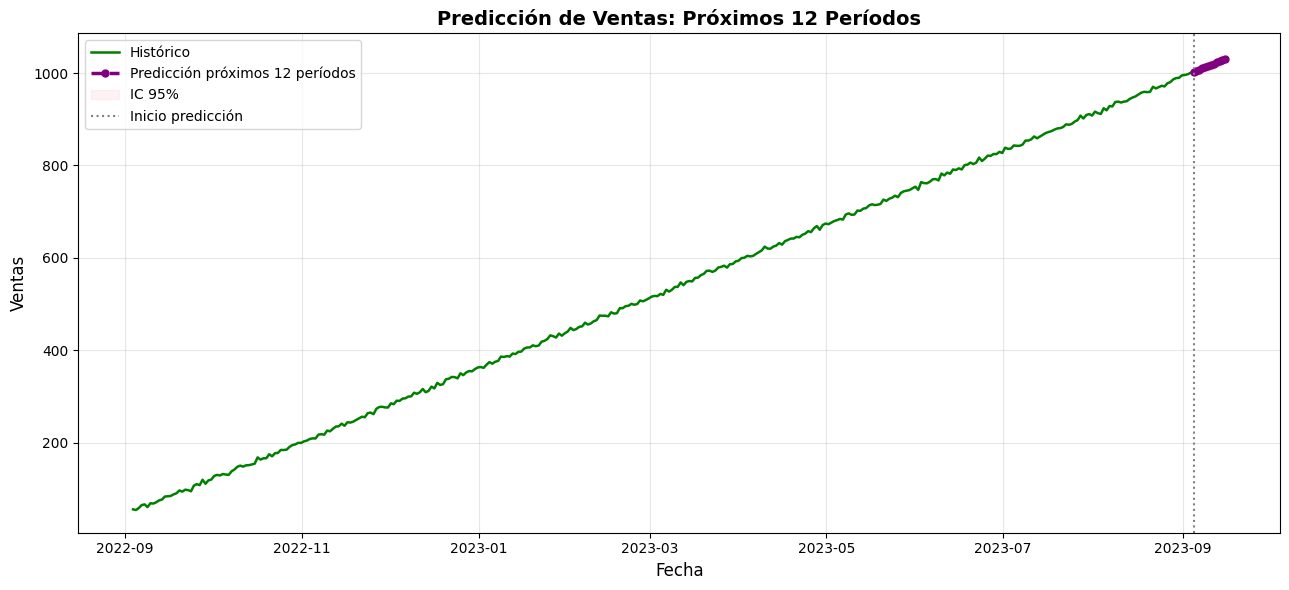


Ventas previstas para los próximos períodos:
                            Predicción  IC inferior (95%)  IC superior (95%)
2023-09-04 17:10:08.079328     1002.22             996.39            1008.05
2023-09-05 17:10:08.079328     1004.89             999.06            1010.72
2023-09-06 17:10:08.079328     1007.49            1001.64            1013.33
2023-09-07 17:10:08.079328     1010.08            1004.23            1015.94
2023-09-08 17:10:08.079328     1012.68            1006.81            1018.55
2023-09-09 17:10:08.079328     1015.28            1009.40            1021.16
2023-09-10 17:10:08.079328     1017.88            1011.98            1023.77
2023-09-11 17:10:08.079328     1020.47            1014.57            1026.38
2023-09-12 17:10:08.079328     1023.07            1017.15            1028.99
2023-09-13 17:10:08.079328     1025.67            1019.73            1031.60
2023-09-14 17:10:08.079328     1028.27            1022.32            1034.22
2023-09-15 17:10:08.079328    

In [44]:
# Predicción de los próximos 12 períodos (para planificación del almacén)
n_futuro = 12

# Reentrenamos con todos los datos disponibles
modelo_final = ARIMA(serie, order=(int(mejor_p), int(mejor_d), int(mejor_q)))
resultado_final = modelo_final.fit()

pred_futuro = resultado_final.get_forecast(steps=n_futuro)
pred_media  = pred_futuro.predicted_mean
pred_ic     = pred_futuro.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(serie.index,
        serie.values,
        color='green',
        linewidth=1.8,
        label='Histórico')
ax.plot(pred_media.index,
        pred_media.values,
        color='purple',
        linewidth=2.5,
        marker='o',
        markersize=5,
        linestyle='--',
        label=f'Predicción próximos {n_futuro} períodos')
ax.fill_between(pred_ic.index,
                pred_ic.iloc[:, 0],
                pred_ic.iloc[:, 1],
                color='pink',
                alpha=0.2,
                label='IC 95%')

ax.axvline(pred_media.index[0],
           color='gray',
           linestyle=':',
           linewidth=1.5,
           label='Inicio predicción')
ax.set_title(f'Predicción de Ventas: Próximos {n_futuro} Períodos',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Ventas', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVentas previstas para los próximos períodos:")
resumen_futuro = pd.DataFrame({
    'Predicción': pred_media.round(2),
    'IC inferior (95%)': pred_ic.iloc[:, 0].round(2),
    'IC superior (95%)': pred_ic.iloc[:, 1].round(2)
})
print(resumen_futuro.to_string())

Esta es la predicción directamente útil para el objetivo del negocio: **estimar el ritmo de ventas de los próximos 12 meses**. El modelo se reentrena con **todos los datos disponibles** (train + test) para obtener la predicción más exacta posible. La tabla incluye el intervalo de confianza al 95%, lo que permite hacer una planificación conservadora y realista en base a las ventas del año anterior.

# **PASO 5: Guardado del modelo**

In [45]:
os.makedirs('models', exist_ok=True)

# Guardamos el modelo final (entrenado con todos los datos)
resultado_final.save('models/arima_sales.pkl')

print("Modelo guardado:")
print(f"   - models/arima_sales.pkl")
print(f"   - Parámetros: ARIMA({int(mejor_p)}, {int(mejor_d)}, {int(mejor_q)})")
print(f"   - Entrenado con: {len(serie)} observaciones")
print(f"   - Periodo cubierto: {serie.index.min().date()} → {serie.index.max().date()}")

Modelo guardado:
   - models/arima_sales.pkl
   - Parámetros: ARIMA(0, 2, 3)
   - Entrenado con: 366 observaciones
   - Periodo cubierto: 2022-09-03 → 2023-09-03


Guardado del modelo con `save()` de statsmodels (método nativo para modelos ARIMA, he leído que en este caso es más fiable que `joblib`). El fichero `arima_sales.pkl` guarda el modelo entrenado con todos los datos históricos y puede cargarse en cualquier momento con `ARIMAResults.load('models/arima_sales.pkl')` para crear nuevas predicciones sin necesidad de reentrenar desde cero.

## Conclusiones finales

- **Tensor**: la unidad mínima de tiempo de la serie es mensual (un dato por mes), pero puede ser semana o día.
- **Tendencia**: la serie presenta una tendencia creciente regular, consistente con el crecimiento de ventas descrito en el enunciado del proyecto. Las gráficas lo confirma visualmente.
- **Estacionariedad**: el test ADF indica que la serie no es estacionaria en su forma original (presencia de tendencia). El parámetro `d` del ARIMA aplica la diferenciación necesaria para poder trabajar con ella.
- **Variabilidad y ruido**: los residuos de la descomposición muestran cierta variabilidad, pero sin estructura clara, lo que nos indica que el modelo aditivo es el adecuado.
- El modelo ARIMA elegido por menor AIC captura correctamente la tendencia creciente y produce predicciones con errores bastante aceptables sobre el conjunto de test.
- **Para la dirección**: es recomendable usar el **límite superior del intervalo de confianza** al 95% para dimensionar el espacio restante, garantizando capacidad suficiente incluso en escenarios de mayor crecimiento futuro.